# Deep Learning Self-Learning Assignment
## Exploring Word Representations: From Traditional Word Embeddings to Transformers

**Name:** Nitheeswaran M 24BAD079 
**Course:** 24ADI006 Deep Learning  
**Objective:** Explore traditional, static, neural, and contextual text representations using TF-IDF, Word2Vec, FastText, Keras Embeddings, and BERT.

### Experiments in this notebook
1. Create and preprocess a common text dataset
2. Generate TF-IDF representations
3. Train Word2Vec using Skip-gram
4. Train FastText and test out-of-vocabulary handling
5. Build a TensorFlow/Keras Embedding model
6. Generate contextual embeddings using BERT
7. Find semantically similar words using cosine similarity
8. Visualize embeddings using PCA and t-SNE
9. Compare static and contextual word representations


In [1]:
!pip -q install gensim transformers sentencepiece scikit-learn tensorflow


In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from gensim.models import Word2Vec, FastText

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

from transformers import AutoTokenizer, AutoModel

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [3]:
documents = [
    "machine learning is a branch of artificial intelligence",
    "deep learning uses neural networks for complex tasks",
    "python is widely used for machine learning and data science",
    "tensorflow is a popular deep learning framework",
    "pytorch is used to build neural network models",
    "data science uses statistics programming and machine learning",
    "artificial intelligence enables machines to perform intelligent tasks",
    "neural networks learn patterns from large datasets",
    "dogs and cats are common household pets",
    "dogs are loyal animals and cats are independent animals",
    "lions and tigers are wild animals",
    "elephants are large wild animals",
    "india and japan are countries in asia",
    "france and germany are countries in europe",
    "students learn programming using python",
    "software engineers use python and java for development",
    "banks provide financial services to customers",
    "customers deposit money into a bank account",
    "a fisherman sat near the bank of the river",
    "the river bank was covered with green plants"
]

print("Number of documents:", len(documents))

for i, doc in enumerate(documents[:5], start=1):
    print(i, doc)


Number of documents: 20
1 machine learning is a branch of artificial intelligence
2 deep learning uses neural networks for complex tasks
3 python is widely used for machine learning and data science
4 tensorflow is a popular deep learning framework
5 pytorch is used to build neural network models


In [4]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text.split()

tokenized_sentences = [preprocess(doc) for doc in documents]

for sentence in tokenized_sentences[:5]:
    print(sentence)


['machine', 'learning', 'is', 'a', 'branch', 'of', 'artificial', 'intelligence']
['deep', 'learning', 'uses', 'neural', 'networks', 'for', 'complex', 'tasks']
['python', 'is', 'widely', 'used', 'for', 'machine', 'learning', 'and', 'data', 'science']
['tensorflow', 'is', 'a', 'popular', 'deep', 'learning', 'framework']
['pytorch', 'is', 'used', 'to', 'build', 'neural', 'network', 'models']


# Part A - TF-IDF

TF-IDF is a traditional statistical representation. It assigns a high weight to terms that are important in one document but relatively uncommon across the full collection.

## Generate TF-IDF Vectors

In [5]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(documents)

feature_names = tfidf.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names
)

print("TF-IDF matrix shape:", tfidf_df.shape)
tfidf_df.head()


TF-IDF matrix shape: (20, 87)


,account,and,animals,are,artificial,asia,bank,banks,branch,build,...,tigers,to,use,used,uses,using,was,widely,wild,with
0,0.0,0.000000,0.0,0.0,0.396013,0.0,0.0,0.0,0.450519,0.000000,...,0.0,0.00000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0
1,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.00000,0.0,0.000000,0.364967,0.0,0.0,0.000000,0.0,0.0
2,0.0,0.216384,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.00000,0.0,0.345071,0.000000,0.0,0.0,0.392565,0.0,0.0
3,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.00000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0
4,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.390468,...,0.0,0.30971,0.0,0.343228,0.000000,0.0,0.0,0.000000,0.0,0.0


## Display Important TF-IDF Words for One Document

In [6]:
document_index = 0

scores = tfidf_df.iloc[document_index]
top_words = scores[scores > 0].sort_values(ascending=False)

print("Document:", documents[document_index])
print("\nTF-IDF scores:")
print(top_words)


Document: machine learning is a branch of artificial intelligence

TF-IDF scores:
branch          0.450519
artificial      0.396013
intelligence    0.396013
of              0.396013
machine         0.357340
is              0.327344
learning        0.302834
Name: 0, dtype: float64


# Part B - Word2Vec

Word2Vec creates dense word vectors based on surrounding words.

We use the **Skip-gram** architecture (`sg=1`), which learns to predict context words from a target word.

## Train Word2Vec

In [7]:
word2vec_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=50,
    window=3,
    min_count=1,
    workers=1,
    sg=1,
    epochs=300
)

print("Vocabulary size:", len(word2vec_model.wv))
print("Vector dimension:", word2vec_model.vector_size)


Vocabulary size: 88
Vector dimension: 50


## Inspect a Word Vector

In [8]:
query_word = "python"

print("Word:", query_word)
print("Vector shape:", word2vec_model.wv[query_word].shape)
print(word2vec_model.wv[query_word][:10])


Word: python
Vector shape: (50,)
[-1.7386055e-04 -2.6126516e-03 -2.0481808e-01  3.1680316e-02
 -4.0513407e-02 -1.8311776e-01  2.5724846e-01  2.2943223e-01
 -1.9962040e-01 -1.7789589e-01]


## Find Five Semantically Similar Words  

In [9]:
query_words = ["python", "machine", "animals", "bank"]

for word in query_words:
    print(f"\nTop 5 words similar to '{word}':")
    if word in word2vec_model.wv:
        for similar_word, score in word2vec_model.wv.most_similar(word, topn=5):
            print(f"{similar_word:15s} {score:.4f}")
    else:
        print("Word not found in vocabulary.")



Top 5 words similar to 'python':
software        0.9941
for             0.9934
using           0.9923
programming     0.9921
widely          0.9920

Top 5 words similar to 'machine':
science         0.9951
widely          0.9933
learning        0.9929
statistics      0.9924
data            0.9918

Top 5 words similar to 'animals':
independent     0.9923
loyal           0.9918
and             0.9907
cats            0.9903
wild            0.9892

Top 5 words similar to 'bank':
river           0.9962
the             0.9951
was             0.9936
fisherman       0.9928
covered         0.9920


# Part C - FastText

FastText represents words using character-level subwords. Therefore, it can generate embeddings for rare or unseen words by using smaller character patterns.

## Train FastText

In [10]:
fasttext_model = FastText(
    sentences=tokenized_sentences,
    vector_size=50,
    window=3,
    min_count=1,
    workers=1,
    sg=1,
    epochs=300
)

print("FastText model trained.")


FastText model trained.


## FastText Similar Words

In [11]:
for word in ["python", "machine", "animals"]:
    print(f"\nTop 5 FastText words similar to '{word}':")
    for similar_word, score in fasttext_model.wv.most_similar(word, topn=5):
        print(f"{similar_word:15s} {score:.4f}")



Top 5 FastText words similar to 'python':
development     0.9995
programming     0.9994
widely          0.9994
engineers       0.9993
statistics      0.9993

Top 5 FastText words similar to 'machine':
machines        0.9999
perform         0.9995
enables         0.9995
tasks           0.9995
intelligent     0.9994

Top 5 FastText words similar to 'animals':
independent     0.9996
dogs            0.9994
tigers          0.9993
loyal           0.9993
common          0.9991


## FastText Out-of-Vocabulary Experiment

`computerr` is deliberately misspelled and is not part of the original training vocabulary.
Unlike standard Word2Vec, FastText can still generate a vector because it uses character n-grams.

In [12]:
oov_word = "computerr"

print("Is OOV word in original FastText vocabulary?")
print(oov_word in fasttext_model.wv.key_to_index)

oov_vector = fasttext_model.wv[oov_word]

print("\nGenerated OOV vector shape:", oov_vector.shape)
print("First 10 values:")
print(oov_vector[:10])

print("\nWords similar to the OOV word:")
for similar_word, score in fasttext_model.wv.most_similar(oov_word, topn=5):
    print(f"{similar_word:15s} {score:.4f}")


Is OOV word in original FastText vocabulary?
False

Generated OOV vector shape: (50,)
First 10 values:
[-0.08470912 -0.00036464 -0.09680521 -0.04544553 -0.06101246  0.0327454
 -0.04024293  0.0806112  -0.02669484  0.06442726]

Words similar to the OOV word:
complex         0.9992
patterns        0.9990
programming     0.9989
datasets        0.9989
models          0.9989


# Part D - TensorFlow / Keras Embedding Layer

The Keras `Embedding` layer learns dense vector representations during neural-network training.

## Convert Text to Integer Sequences

In [13]:
tokenizer_keras = Tokenizer(oov_token="<OOV>")
tokenizer_keras.fit_on_texts(documents)

sequences = tokenizer_keras.texts_to_sequences(documents)

max_length = max(len(seq) for seq in sequences)
padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post"
)

vocab_size = len(tokenizer_keras.word_index) + 1

print("Vocabulary size:", vocab_size)
print("Maximum sequence length:", max_length)
print("\nExample sequence:")
print(sequences[0])
print("\nPadded sequence:")
print(padded_sequences[0])


Vocabulary size: 90
Maximum sequence length: 10

Example sequence:
[8, 4, 5, 6, 35, 15, 16, 17]

Padded sequence:
[ 8  4  5  6 35 15 16 17  0  0]


## Create Simple Training Labels

For demonstration, the sentences are grouped into broad categories:

- 0 = Artificial Intelligence / Programming
- 1 = Animals
- 2 = Geography
- 3 = Banking / River-bank context


In [14]:
labels = np.array([
    0,0,0,0,0,0,0,0,
    1,1,1,1,
    2,2,
    0,0,
    3,3,3,3
])

print("Labels shape:", labels.shape)


Labels shape: (20,)


## Build and Train Keras Embedding Model

In [15]:
embedding_dim = 16

keras_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_length,
        name="embedding"
    ),
    GlobalAveragePooling1D(),
    Dense(16, activation="relu"),
    Dense(4, activation="softmax")
])

keras_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = keras_model.fit(
    padded_sequences,
    labels,
    epochs=100,
    verbose=0
)

print("Training complete.")
print("Final training accuracy:",
      round(history.history["accuracy"][-1], 4))


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1791216123.657526      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791216123.661346      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1791216126.558445    1340 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Training complete.
Final training accuracy: 0.9


## Extract Learned Keras Embeddings

In [16]:
embedding_layer = keras_model.get_layer("embedding")
keras_embedding_matrix = embedding_layer.get_weights()[0]

print("Embedding matrix shape:", keras_embedding_matrix.shape)

word = "python"
word_index = tokenizer_keras.word_index[word]

print("\nWord:", word)
print("Index:", word_index)
print("Embedding:")
print(keras_embedding_matrix[word_index])


Embedding matrix shape: (90, 16)

Word: python
Index: 11
Embedding:
[ 0.1738117  -0.11021607  0.14993511  0.12329819 -0.19152792 -0.17325322
  0.16447075 -0.21913378  0.19041003 -0.17744759 -0.16002437  0.13627958
  0.14936692 -0.21498325  0.1944734  -0.15045401]


# Part E - BERT Contextual Embeddings

Traditional Word2Vec gives one fixed vector for a word.

BERT is **contextual**: the representation of a word changes according to the sentence in which it appears.

We demonstrate this with the word **bank**:
- financial bank
- river bank


## Load Pretrained BERT

In [17]:
bert_model_name = "bert-base-uncased"

bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
bert_model = AutoModel.from_pretrained(bert_model_name)

print("BERT loaded:", bert_model_name)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded: bert-base-uncased


## Function to Extract a Contextual Word Embedding

In [18]:
def get_contextual_embedding(sentence, target_word):
    inputs = bert_tokenizer(
        sentence,
        return_tensors="pt",
        return_offsets_mapping=True
    )

    offsets = inputs.pop("offset_mapping")[0].tolist()

    with tf.device("/CPU:0"):
        pass

    outputs = bert_model(**inputs)
    hidden_states = outputs.last_hidden_state[0].detach().numpy()

    sentence_lower = sentence.lower()
    start_char = sentence_lower.find(target_word.lower())
    end_char = start_char + len(target_word)

    token_indices = []

    for i, (start, end) in enumerate(offsets):
        if start < end_char and end > start_char:
            token_indices.append(i)

    if not token_indices:
        raise ValueError("Target word could not be aligned with BERT tokens.")

    return hidden_states[token_indices].mean(axis=0)


## Compare the Word 'Bank' in Two Contexts

In [19]:
sentence1 = "The customer deposited money in the bank."
sentence2 = "The fisherman sat on the bank of the river."

bank_finance = get_contextual_embedding(sentence1, "bank")
bank_river = get_contextual_embedding(sentence2, "bank")

similarity = cosine_similarity(
    bank_finance.reshape(1, -1),
    bank_river.reshape(1, -1)
)[0][0]

print("Sentence 1:", sentence1)
print("Sentence 2:", sentence2)
print("\nBERT vector size:", len(bank_finance))
print("Cosine similarity between the two 'bank' embeddings:",
      round(float(similarity), 4))


Sentence 1: The customer deposited money in the bank.
Sentence 2: The fisherman sat on the bank of the river.

BERT vector size: 768
Cosine similarity between the two 'bank' embeddings: 0.4979


### Interpretation

The similarity is not expected to be exactly 1 because BERT generates the embedding of **bank** using its surrounding context.

In the first sentence, **bank** means a financial institution.  
In the second sentence, **bank** means the side of a river.

This demonstrates the main advantage of contextual embeddings over static embeddings such as Word2Vec.

# Part F - Embedding Visualization

We now reduce 50-dimensional Word2Vec vectors to two dimensions so that semantic relationships can be visually inspected.

## PCA Visualization

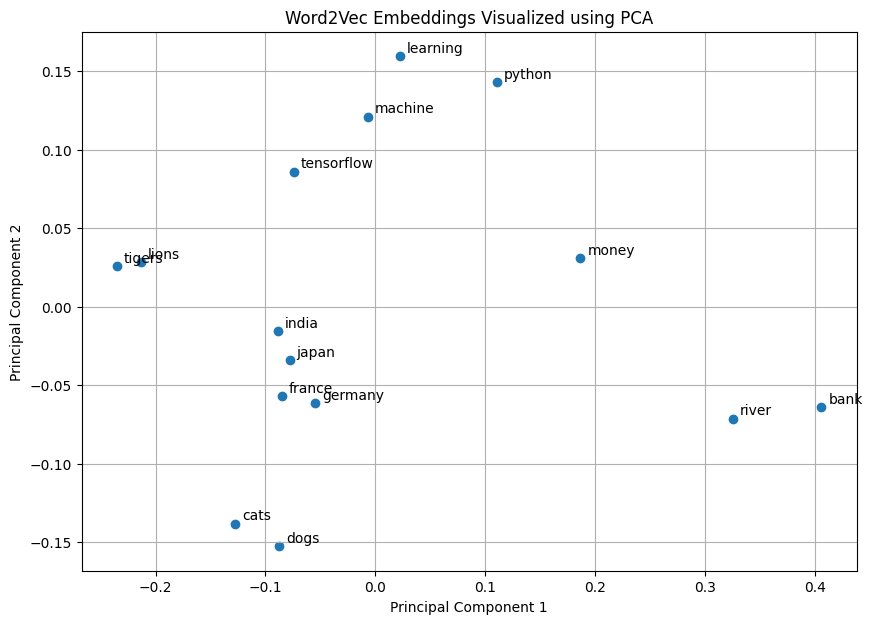

In [20]:
selected_words = [
    "machine", "learning", "python", "tensorflow",
    "dogs", "cats", "lions", "tigers",
    "india", "japan", "france", "germany",
    "bank", "money", "river"
]

valid_words = [w for w in selected_words if w in word2vec_model.wv]
vectors = np.array([word2vec_model.wv[w] for w in valid_words])

pca = PCA(n_components=2)
points_2d = pca.fit_transform(vectors)

plt.figure(figsize=(10, 7))
plt.scatter(points_2d[:, 0], points_2d[:, 1])

for i, word in enumerate(valid_words):
    plt.annotate(
        word,
        (points_2d[i, 0], points_2d[i, 1]),
        xytext=(5, 3),
        textcoords="offset points"
    )

plt.title("Word2Vec Embeddings Visualized using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()


## t-SNE Visualization

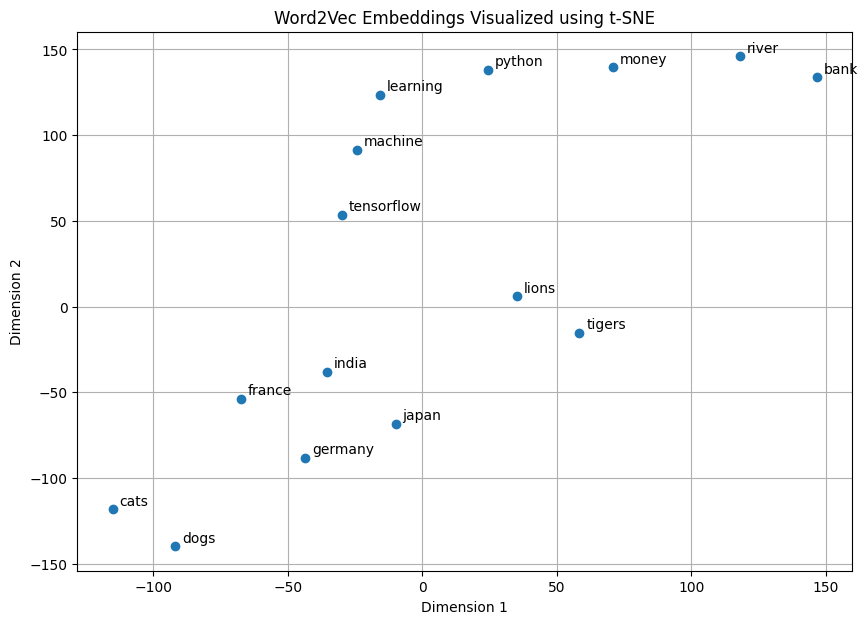

In [21]:
tsne = TSNE(
    n_components=2,
    perplexity=5,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

tsne_points = tsne.fit_transform(vectors)

plt.figure(figsize=(10, 7))
plt.scatter(tsne_points[:, 0], tsne_points[:, 1])

for i, word in enumerate(valid_words):
    plt.annotate(
        word,
        (tsne_points[i, 0], tsne_points[i, 1]),
        xytext=(5, 3),
        textcoords="offset points"
    )

plt.title("Word2Vec Embeddings Visualized using t-SNE")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid()
plt.show()


# Part G - Final Comparison

| Technique | Vector Type | Semantic Representation | OOV Handling | Context Sensitive | Computational Requirement |
|---|---|---|---|---|---|
| One-Hot | Sparse | Very Low | No | No | Low |
| Bag of Words | Sparse | Low | No | No | Low |
| TF-IDF | Sparse | Limited | No | No | Low |
| Word2Vec | Dense | Good | No | No | Medium |
| FastText | Dense | Good | Yes, using subwords | No | Medium |
| Keras Embedding | Dense | Learned for task | OOV token possible | Usually No | Medium |
| BERT | Dense contextual | Very High | Subword tokenization | Yes | High |

## Key Observations
- TF-IDF identifies statistically important words but does not directly understand semantic similarity.
- Word2Vec learns static semantic relationships from neighboring words.
- FastText improves Word2Vec by using character subwords and can represent unseen words.
- Keras embeddings are learned as part of a neural-network task.
- BERT produces contextual representations, so the same word can have different embeddings in different sentences.
- PCA and t-SNE make high-dimensional semantic relationships easier to inspect visually.


# Conclusion

This experiment demonstrates the progression of text representation techniques from sparse statistical vectors to dense contextual embeddings.

Traditional techniques such as TF-IDF are simple and computationally inexpensive but have limited semantic understanding. Word2Vec learns meaningful static semantic vectors, while FastText improves robustness for rare and out-of-vocabulary words. Neural embeddings using TensorFlow/Keras can be optimized for a particular learning task. Transformer-based models such as BERT provide the richest representations because the vector for a word depends on its surrounding context.

Therefore, contextual Transformer embeddings provide stronger semantic understanding, although they require significantly more computation than traditional and static embedding approaches.
